In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
sales = pd.read_csv("/content/sales_train_validation.csv")
calendar = pd.read_csv("/content/calendar.csv")
sell_prices = pd.read_csv("/content/sell_prices.csv")

print("Sales:", sales.shape)
print("Calendar:", calendar.shape)
print("Prices:", sell_prices.shape)

Sales: (1334, 1919)
Calendar: (1969, 14)
Prices: (269634, 4)


In [ ]:
calendar["date"] = pd.to_datetime(calendar["date"])

date_mapping = dict(zip(calendar["d"], calendar["date"]))
sales = sales.rename(columns=date_mapping)

In [ ]:
missing_rows = sales[sales.isnull().any(axis=1)]

print("Rows with missing values:", len(missing_rows))
print("Missing values:", sales.isnull().sum().sum())

sales = sales.drop(index=missing_rows.index).reset_index(drop=True)

print("Clean sales shape:", sales.shape)

Rows with missing values: 1
Missing values: 176
Clean sales shape: (1333, 1919)


In [ ]:
id_cols = [
    "id", "item_id", "dept_id",
    "cat_id", "store_id", "state_id"
]

sales_long = sales.melt(
    id_vars=id_cols,
    var_name="date",
    value_name="sales"
)

sales_long["date"] = pd.to_datetime(sales_long["date"])

print(sales_long.shape)

(2550029, 8)


In [ ]:
sales_long = sales_long.merge(
    calendar[["date", "wm_yr_wk", "weekday", "event_name_1"]],
    on="date",
    how="left"
)

print(sales_long.shape)

(2550029, 11)


In [ ]:
sell_prices = sell_prices.dropna(
    subset=["wm_yr_wk", "sell_price"]
).copy()

sell_prices["wm_yr_wk"] = sell_prices["wm_yr_wk"].astype(int)

In [ ]:
sales_long = sales_long.merge(
    sell_prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

print(sales_long.shape)
print("Missing prices:", sales_long["sell_price"].isna().sum())

(2550029, 12)
Missing prices: 735371


In [ ]:
daily_sales = sales.iloc[:, 6:].sum()

print(daily_sales.describe())
print("Overall zero-sales %:",
      (sales.iloc[:, 6:] == 0).mean().mean() * 100)

count    1913.000000
mean     1110.062206
std       329.998871
min         0.000000
25%       858.000000
50%      1085.000000
75%      1305.000000
max      2256.000000
dtype: float64
Overall zero-sales %: 68.64008213239927


In [ ]:
weekday_sales = (
    sales_long.groupby("weekday")["sales"]
    .mean()
    .sort_values(ascending=False)
)

print(weekday_sales)

weekday
Saturday     1.054613
Sunday       1.038547
Friday       0.825921
Monday       0.801239
Tuesday      0.715973
Thursday     0.697919
Wednesday    0.693506
Name: sales, dtype: float64


In [ ]:
top_items = (
    sales_long.groupby("item_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print(top_items.head(10))

item_id
HOBBIES_1_348      22744.0
HOBBIES_1_371      22595.0
HOBBIES_1_268      18904.0
HOBBIES_1_178      15808.0
HOBBIES_1_256      15419.0
HOBBIES_1_254      15041.0
HOUSEHOLD_1_118    14604.0
HOBBIES_1_370      14565.0
HOBBIES_1_341      14152.0
HOBBIES_1_048      13867.0
Name: sales, dtype: float64


In [ ]:
selected_item = "HOBBIES_1_268"

model_data = sales_long[
    sales_long["item_id"] == selected_item
].copy()

print(model_data.shape)

(1913, 12)


In [ ]:
print("Mean demand:", model_data["sales"].mean())
print("Std demand:", model_data["sales"].std())
print("Zero-demand %:",
      (model_data["sales"] == 0).mean() * 100)

Mean demand: 9.881860951385258
Std demand: 13.903494725165508
Zero-demand %: 20.491374803972818


In [ ]:
model_data["month"] = model_data["date"].dt.month
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["day_of_month"] = model_data["date"].dt.day

model_data["lag_1"] = model_data["sales"].shift(1)
model_data["lag_7"] = model_data["sales"].shift(7)

model_data["rolling_mean_7"] = (
    model_data["sales"].shift(1).rolling(7).mean()
)

model_data["rolling_std_7"] = (
    model_data["sales"].shift(1).rolling(7).std()
)

model_data["target"] = model_data["sales"].shift(-1)

In [ ]:
features = [
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "month",
    "day_of_week",
    "day_of_month",
    "sell_price"
]

model_df = model_data.dropna(
    subset=features + ["target"]
).copy()

X = model_df[features]
y = model_df["target"]

print("Model data:", model_df.shape)

Model data: (1905, 20)


In [ ]:
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape, X_test.shape)

(1524, 8) (381, 8)


In [ ]:
baseline_pred = X_test["lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 11.763779527559056
Baseline RMSE: 17.384791374319363


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print("RF MAE:", rf_mae)
print("RF RMSE:", rf_rmse)

RF MAE: 8.594422572178479
RF RMSE: 12.863267900857808


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

print("XGB MAE:", xgb_mae)
print("XGB RMSE:", xgb_rmse)

XGB MAE: 8.633370216750098
XGB RMSE: 12.726451228265978


In [ ]:
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost"],
    "MAE": [baseline_mae, rf_mae, xgb_mae],
    "RMSE": [baseline_rmse, rf_rmse, xgb_rmse]
})

print(results.round(3))

           Model     MAE    RMSE
0       Baseline  11.764  17.385
1  Random Forest   8.594  12.863
2        XGBoost   8.633  12.726


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
2  rolling_mean_7    0.288078
0           lag_1    0.146578
7      sell_price    0.120363
5     day_of_week    0.101604
1           lag_7    0.093049
3   rolling_std_7    0.092119
6    day_of_month    0.082166
4           month    0.076043


In [ ]:
daily_mean_demand = y_train.mean()
daily_std_demand = y_train.std()

lead_time = 7
service_level_z = 1.645

lead_time_demand = daily_mean_demand * lead_time

safety_stock = (
    service_level_z *
    daily_std_demand *
    np.sqrt(lead_time)
)

reorder_point = lead_time_demand + safety_stock

order_quantity = daily_mean_demand * 14

print("Mean demand:", daily_mean_demand)
print("Demand std:", daily_std_demand)
print("Lead-time demand:", lead_time_demand)
print("Safety stock:", safety_stock)
print("Reorder point:", reorder_point)
print("Order quantity:", order_quantity)

Mean demand: 9.600393700787402
Demand std: 14.273145370522812
Lead-time demand: 67.20275590551181
Safety stock: 62.12045261179039
Reorder point: 129.3232085173022
Order quantity: 134.40551181102362


In [ ]:
initial_inventory = reorder_point

inventory = initial_inventory
orders_in_transit = []
inventory_history = []
stockout_days = 0

for day, demand in enumerate(y_test):

    arriving_orders = [
        qty
        for arrival_day, qty in orders_in_transit
        if arrival_day == day
    ]

    for qty in arriving_orders:
        inventory += qty

    orders_in_transit = [
        (arrival_day, qty)
        for arrival_day, qty in orders_in_transit
        if arrival_day != day
    ]

    inventory -= demand

    if inventory < 0:
        stockout_days += 1

    if inventory <= reorder_point and not orders_in_transit:
        orders_in_transit.append(
            (day + lead_time, order_quantity)
        )

    inventory_history.append(inventory)

In [ ]:
print("Final inventory:", inventory)
print("Minimum inventory:", min(inventory_history))
print("Stockout days:", stockout_days)
print(
    "Stockout rate:",
    stockout_days / len(y_test)
)

Final inventory: 187.89407465903426
Minimum inventory: 6.189350249585573
Stockout days: 0
Stockout rate: 0.0


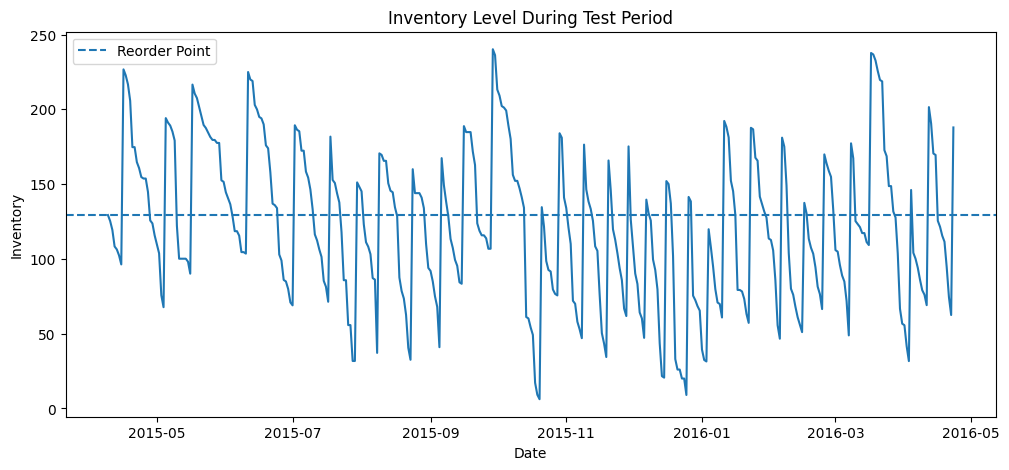

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_dates := model_df.iloc[split_index:]["date"],
    inventory_history
)

plt.axhline(
    reorder_point,
    linestyle="--",
    label="Reorder Point"
)

plt.xlabel("Date")
plt.ylabel("Inventory")
plt.title("Inventory Level During Test Period")
plt.legend()
plt.show()

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Selected SKU",
        "Observations",
        "Train observations",
        "Test observations",
        "Lead time",
        "Service level",
        "Safety stock",
        "Reorder point",
        "Order quantity",
        "Minimum inventory",
        "Final inventory",
        "Stockout days"
    ],
    "Value": [
        selected_item,
        len(model_df),
        len(X_train),
        len(X_test),
        lead_time,
        "95%",
        round(safety_stock, 2),
        round(reorder_point, 2),
        round(order_quantity, 2),
        round(min(inventory_history), 2),
        round(inventory, 2),
        stockout_days
    ]
})

print(summary)

                Metric          Value
0         Selected SKU  HOBBIES_1_268
1         Observations           1905
2   Train observations           1524
3    Test observations            381
4            Lead time              7
5        Service level            95%
6         Safety stock          62.12
7        Reorder point         129.32
8       Order quantity         134.41
9    Minimum inventory           6.19
10     Final inventory         187.89
11       Stockout days              0
